# 📋 Ejercicio Clase 2 — Validación Temporal y Backtesting: Siniestralidad Alta GMM
## Diplomado ML en Seguros · Subtema 4

---

## Contexto

**SaludTotal** tiene un modelo GMM para predecir siniestros de alto costo entrenado en **2018–2020**. Lleva en producción **sin re-entrenar**. El mercado cambió: la expansión de servicios médicos en zonas antes rurales invirtió la relación entre zona geográfica y riesgo de siniestro grave.

Además, los planes con deducible alto — que antes atraían perfiles sanos — ahora coexisten con coberturas ampliadas que atraen perfiles más complejos.

---

## Lo que practicarás

| Parte | Concepto nuevo (además de lo de Clase 1) |
|-------|------------------------------------------|
| 3 | Evaluar el modelo congelado: ¿baja el AUC? |
| 4 | Walk-Forward: cuantificar la ganancia de re-entrenar |
| 5 | F2-Score: comparar τ=0.50 vs τ_costos |
| 6 | Ratio A/E: detectar sesgo sistemático |
| 7 | Backtesting económico y visualización integrada |

---

## Costos

| Parámetro | Valor |
|-----------|-------|
| C_FP (gestor preventivo innecesario) | $3,800 MXN |
| C_FN (hospitalización no gestionada) | $170,000 MXN |
| Reducción de costo si se gestiona | 38% |
| τ por costos | **calcúlalo tú** |

**No cambies `random_state=2024`.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, fbeta_score, confusion_matrix

np.random.seed(2024)
C_FP   = 3_800
C_FN   = 170_000
RED_FN = 0.38

# 🔧 COMPLETA
tau_c = C_FP / (C_FP + C_FN)
print(f"τ por costos = {tau_c:.4f}  (Ratio C_FN/C_FP = {C_FN/C_FP:.0f}x)")

τ por costos = 0.0219  (Ratio C_FN/C_FP = 45x)


---
## Parte 1 — Portafolio SaludTotal 2018–2024 (NO modificar)

In [2]:
np.random.seed(2024)
ANIOS  = list(range(2018, 2025))
N_ANIO = {a: 380 + (a-2018)*48 for a in range(2018,2025)}

registros = []
for anio in ANIOS:
    n    = N_ANIO[anio]
    edad = np.clip(np.random.normal(37 + (anio-2018)*0.8, 12, n).astype(int), 18, 70)
    bmi  = np.clip(np.random.normal(27.3, 5.1, n), 16, 45).round(1)
    prex = np.random.binomial(1, 0.24 + 0.013*(anio>=2021)*min(anio-2020,3), n)
    fum  = np.random.binomial(1, 0.14, n)
    sin2 = np.random.choice([0,1,2,3], n, p=[.65,.22,.09,.04])
    ded  = np.random.choice([10,20,50,100], n, p=[.20,.35,.30,.15])
    zona = np.random.choice([1,2,3,4], n, p=[.28,.37,.22,.13])

    # Drift estructural: coeficientes que cambian de signo
    coef_zona = -0.12 + 0.075*(anio - 2018)   # de -0.12 (2018) a +0.39 (2024)
    coef_ded  = -0.011 + 0.004*(anio - 2018)  # de -0.011 (2018) a +0.013 (2024)

    lo = (-5.10 + 0.028*edad + 0.065*np.maximum(bmi-25,0)
          + 1.25*prex + 0.48*fum + 0.60*sin2
          + coef_ded*ded + coef_zona*zona
          + np.random.normal(0, 0.78, n))
    sa = (np.random.rand(n) < 1/(1+np.exp(-lo))).astype(int)

    for i in range(n):
        registros.append({'anio':anio,'edad':edad[i],'bmi':bmi[i],
                          'preexistente':prex[i],'fumador':fum[i],
                          'siniestros_2yr':sin2[i],'deducible_k':ded[i],
                          'zona_riesgo':zona[i],'siniestro_alto':sa[i]})

df = pd.DataFrame(registros).sort_values('anio').reset_index(drop=True)
FEATURES = ['edad','bmi','preexistente','fumador','siniestros_2yr','deducible_k','zona_riesgo']

print(f"Portafolio SaludTotal: {len(df):,} pólizas 2018–2024")
coef_zona_anio = {a: round(-0.12+0.075*(a-2018),3) for a in ANIOS}
for a in ANIOS:
    s = df[df.anio==a]
    cz = coef_zona_anio[a]
    sentido = "zona alta = BAJO riesgo" if cz < 0 else "zona alta = ALTO riesgo"
    print(f"  {a}: {s.siniestro_alto.mean()*100:.1f}%  n={len(s)}  coef_zona={cz:+.3f}  ({sentido})")

Portafolio SaludTotal: 3,668 pólizas 2018–2024
  2018: 3.7%  n=380  coef_zona=-0.120  (zona alta = BAJO riesgo)
  2019: 5.6%  n=428  coef_zona=-0.045  (zona alta = BAJO riesgo)
  2020: 4.4%  n=476  coef_zona=+0.030  (zona alta = ALTO riesgo)
  2021: 7.1%  n=524  coef_zona=+0.105  (zona alta = ALTO riesgo)
  2022: 13.3%  n=572  coef_zona=+0.180  (zona alta = ALTO riesgo)
  2023: 17.3%  n=620  coef_zona=+0.255  (zona alta = ALTO riesgo)
  2024: 18.3%  n=668  coef_zona=+0.330  (zona alta = ALTO riesgo)


---
## Parte 2 — K-Fold estándar: el AUC ambiguo

### 🔧 2.1 — Calcula el AUC con K-Fold

In [3]:
# 🔧 COMPLETA: K-Fold estándar (5 folds, shuffle=True, random_state=2024)
modelo = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
X_all = df[FEATURES].values
y_all = df['siniestro_alto'].values

# --- TU CÓDIGO AQUÍ ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
scores_kf = cross_val_score(modelo, X_all, y_all, cv=kf, scoring='roc_auc')
auc_kf = scores_kf.mean()

print(f"AUC K-Fold: {auc_kf:.4f}")
print(f"Std entre folds: {scores_kf.std():.4f}")
print()
print("¿A qué año corresponde este número?")
print("Responde en la celda de texto siguiente.")

AUC K-Fold: 0.6638
Std entre folds: 0.0332

¿A qué año corresponde este número?
Responde en la celda de texto siguiente.


### 📝 Pregunta 2.1

En este portafolio, `zona_riesgo` alta significa "bajo riesgo" en 2018 y "alto riesgo" en 2024.

**¿Qué problema concreto genera K-Fold cuando mezcla 2018 con 2024 en el mismo fold?**
¿Qué aprende el modelo sobre `zona_riesgo` cuando los dos años están mezclados?

> Este AUC mezcla el patrón de 2018 (zona alta → bajo riesgo) con el de 2024 (zona alta → alto riesgo).

El modelo aprende una relación promedio que no corresponde a ningún año particular o alguna información concreta.

---
## Parte 3 — El modelo que está en producción

### 🔧 3.1 — Modelo congelado (2018–2020), evalúalo año a año

In [4]:
# 🔧 COMPLETA: entrena el modelo solo con 2018, 2019, 2020
# Luego evalúalo sin re-entrenar en 2022, 2023, 2024

mask_ini = df['anio'].isin([2018, 2019, 2020])
pipe_congelado = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])

# 🔧 ENTRENA el modelo congelado
pipe_congelado.fit(df.loc[mask_ini, FEATURES].values,
                   df.loc[mask_ini, 'siniestro_alto'].values)

print("MODELO CONGELADO — entrenado en 2018–2020:")
print(f"  {'Año':>5}  {'AUC':>8}  {'% alto':>8}  {'Diagnóstico'}")
print("-"*55)

aucs_congelado = []
for at in [2022, 2023, 2024]:
    mte  = df['anio'] == at
    y_te = df.loc[mte, 'siniestro_alto'].values
    # 🔧 PREDICE y calcula AUC
    y_prob_cong = pipe_congelado.predict_proba(df.loc[mte, FEATURES].values)[:,1]
    auc = roc_auc_score(y_te, y_prob_cong)
    aucs_congelado.append(auc)
    tasa = y_te.mean()*100
    diag = "✅" if auc>=0.67 else ("⚠️  Degradación" if auc>=0.63 else "🔴 Re-entrenar")
    print(f"  {at:>5}  {auc:>8.4f}  {tasa:>7.1f}%  {diag}")

print()
print("¿El AUC sube o baja de 2022 a 2024?")
print("¿Qué error concreto comete el modelo sobre zona_riesgo en 2024?")

MODELO CONGELADO — entrenado en 2018–2020:
    Año       AUC    % alto  Diagnóstico
-------------------------------------------------------
   2022    0.5619     13.3%  🔴 Re-entrenar
   2023    0.6295     17.3%  🔴 Re-entrenar
   2024    0.5548     18.3%  🔴 Re-entrenar

¿El AUC sube o baja de 2022 a 2024?
¿Qué error concreto comete el modelo sobre zona_riesgo en 2024?


### 📝 Pregunta 3.1

El modelo congelado aprendió que `zona_riesgo` alta = bajo riesgo.
En 2024 esa relación es al revés.

**¿Qué tipo de paciente está el modelo ignorando en 2024?**
¿Un paciente de zona 4 con alta probabilidad real de siniestro recibe alerta o no?

> Como el modelo fue entrenado del 2018-2020 aprendió la relación equivocada (zona alta = bajo riesgo). 

Al aplicarse en el 2024 un paciente de zona 4 aunque tenga características que lo colocan como alta probabilidad de siniestro, es clasificado como bajo riesgo. En consecuencia no recibe alerta ya que el modelo lo etiqueta como seguro cuando en realidad es más riesgoso, esto genera falsos negativos costosos debido a la caída de tau_c (lo cual se puede ver en la información de arriba).

---
## Parte 4 — Walk-Forward: la ganancia de re-entrenar

### 🔧 4.1 — Loop Walk-Forward 2022–2024

In [9]:
# 🔧 COMPLETA: Walk-Forward comparando AUC y F2 vs el modelo congelado
ANIOS_TEST    = [2022, 2023, 2024]
resultados_wf = []

print(f"  {'Año':>5}  {'Train WF':>14}  {'AUC Cong':>10}  {'AUC WF':>8}  "
      f"{'F2 Cong':>9}  {'F2 WF':>7}  {'Δ AUC':>8}")
print("-"*68)

for i, at in enumerate(ANIOS_TEST):
    # 🔧 Define máscaras
    mask_train = df['anio'] < at
    mask_test  = df['anio'] == at
    X_tr = df.loc[mask_train, FEATURES].values; y_tr = df.loc[mask_train, 'siniestro_alto'].values
    X_te = df.loc[mask_test,  FEATURES].values; y_te = df.loc[mask_test,  'siniestro_alto'].values

    # 🔧 Entrena Walk-Forward y predice
    pipe_wf = Pipeline([('sc',StandardScaler()),
                         ('m', GradientBoostingClassifier(n_estimators=150,max_depth=4,
                                                           learning_rate=0.08,random_state=2024))])
    pipe_wf.fit(df.loc[mask_train,FEATURES].values, df.loc[mask_train,'siniestro_alto'].values)
    yp_wf  = pipe_wf.predict_proba(df.loc[mask_test,FEATURES].values)[:,1]
    auc_wf = roc_auc_score(y_te, yp_wf)
    f2_wf  = fbeta_score(y_te, (yp_wf>=tau_c).astype(int), beta=2, zero_division=0)

    # 🔧 Calcula F2 del modelo congelado sobre este mismo año
    yp_cong = pipe_congelado.predict_proba(X_te)[:,1]
    f2_cong = fbeta_score(y_te, (yp_cong>=tau_c).astype(int), beta=2, zero_division=0)

    anios_tr = sorted(df.loc[mask_train,'anio'].unique())
    resultados_wf.append({'anio':at,'auc_wf':auc_wf,'f2_wf':f2_wf,
                           'auc_cong':aucs_congelado[i],'f2_cong':f2_cong,
                           'y_te':y_te,'yp_wf':yp_wf,'yp_cong':yp_cong})
    print(f"  {at:>5}  {anios_tr[0]}–{anios_tr[-1]}  {aucs_congelado[i]:>10.4f}  "
            f"{auc_wf:>8.4f}  {f2_cong*100:>8.1f}%  {f2_wf*100:>6.1f}%  "
            f"{auc_wf-aucs_congelado[i]:>+7.4f}")

print(f"\n  K-Fold (ambiguo): {auc_kf:.4f}")

    Año        Train WF    AUC Cong    AUC WF    F2 Cong    F2 WF     Δ AUC
--------------------------------------------------------------------
   2022  2018–2021      0.5619    0.5649      33.0%    37.5%  +0.0031
   2023  2018–2022      0.6295    0.6052      43.3%    49.8%  -0.0243
   2024  2018–2023      0.5548    0.6810      34.8%    54.7%  +0.1262

  K-Fold (ambiguo): 0.6638


---
## Parte 5 — F2-Score: por qué τ=0.50 no funciona

### 🔧 5.1 — Compara el impacto de distintos umbrales para el año 2024

In [ ]:
# 🔧 COMPLETA: usando el modelo Walk-Forward de 2024 (train=2018–2023, test=2024)
# calcula para τ = 0.50, 0.20, 0.10, tau_c, 0.01:
#   VP, FP, FN, Recall, F2-Score, Valor neto

r_2024 = [r for r in resultados_wf if r['anio']==2024][0]
y_te24 = r_2024['y_te']
yp24   = r_2024['yp_wf']

print(f"Año 2024 — prevalencia real: {y_te24.mean()*100:.1f}%")
print()
print(f"  {'τ':>8}  {'Alertas':>8}  {'VP':>5}  {'FP':>5}  {'FN':>5}  "
      f"{'Recall':>8}  {'F2%':>7}  {'Valor neto':>13}")
print("-"*75)

for tau in [0.50, 0.20, 0.10, tau_c, 0.01]:
    y_pred = (yp24 >= tau).astype(int)
    if y_pred.sum() == 0: continue
    # 🔧 CALCULA todas las métricas
    cm_  = confusion_matrix(y_te24, y_pred)
    vn_,fp_,fn_,vp_ = cm_.ravel()
    recall_       = vp_/(vp_+fn_) if (vp_+fn_)>0 else 0
    f2_           = fbeta_score(y_te24, y_pred, beta=2, zero_division=0)
    valor_neto_   = vp_ * C_FN * RED_FN - (vp_ + fp_) * C_FP

    print(f"  {tau:>8.4f}  {y_pred.sum():>8,}  {vp_:>5}  {fp_:>5}  {fn_:>5}  "
          f"{recall_*100:>7.1f}%  {f2_*100:>6.1f}%  ${valor_neto_:>11,.0f}")



Año 2024 — prevalencia real: 18.3%

         τ   Alertas     VP     FP     FN    Recall      F2%     Valor neto
---------------------------------------------------------------------------
    0.5000         9      4      5    118      3.3%     4.0%  $    224,200
    0.2000        78     29     49     93     23.8%    25.6%  $  1,577,000
    0.1000       209     67    142     55     54.9%    48.1%  $  3,534,000
    0.0219       591    118    473      4     96.7%    54.7%  $  5,377,000
    0.0100       656    122    534      0    100.0%    53.3%  $  5,388,400


---
## Parte 6 — Ratio A/E: detección de sesgo sistemático

### 🔧 6.1 — Calcula el A/E para congelado y Walk-Forward por año

In [ ]:
# 🔧 COMPLETA: para cada año de test y cada modelo:
# A/E = casos reales / suma de probabilidades predichas

print("RATIO A/E (Actual vs Expected):")
print()
print(f"  {'Año':>5}  {'Modelo':>12}  {'Esperados':>11}  {'Reales':>8}  "
      f"{'A/E':>7}  {'Diagnóstico'}")
print("-"*68)

for r in resultados_wf:
    for nombre, yp in [("Congelado", r['yp_cong']), ("Walk-Fwd", r['yp_wf'])]:
        # 🔧 CALCULA esperados, reales, A/E
        esperados = yp.sum()
        reales    = r['y_te'].sum()
        ae        = reales / esperados if esperados > 0 else float('nan')
        if ae < 0.90:   diag = "⚠️  Sobreestima"
        elif ae > 1.10: diag = "⚠️  Subestima"
        else:           diag = "✅  Calibrado"
        print(f"  {r['anio']:>5}  {nombre:>12}  {esperados:>11.1f}  {reales:>8}  "
              f"{ae:>7.3f}  {diag}")
    print()


RATIO A/E (Actual vs Expected):

    Año        Modelo    Esperados    Reales      A/E  Diagnóstico
--------------------------------------------------------------------
   2022     Congelado         23.1        76    3.296  ⚠️  Subestima
   2022      Walk-Fwd         33.0        76    2.306  ⚠️  Subestima

   2023     Congelado         26.0       107    4.109  ⚠️  Subestima
   2023      Walk-Fwd         45.9       107    2.332  ⚠️  Subestima

   2024     Congelado         25.7       122    4.748  ⚠️  Subestima
   2024      Walk-Fwd         64.3       122    1.899  ⚠️  Subestima



---
## Parte 7 — Backtesting económico y visualización

### 🔧 7.1 — Figura con 4 paneles

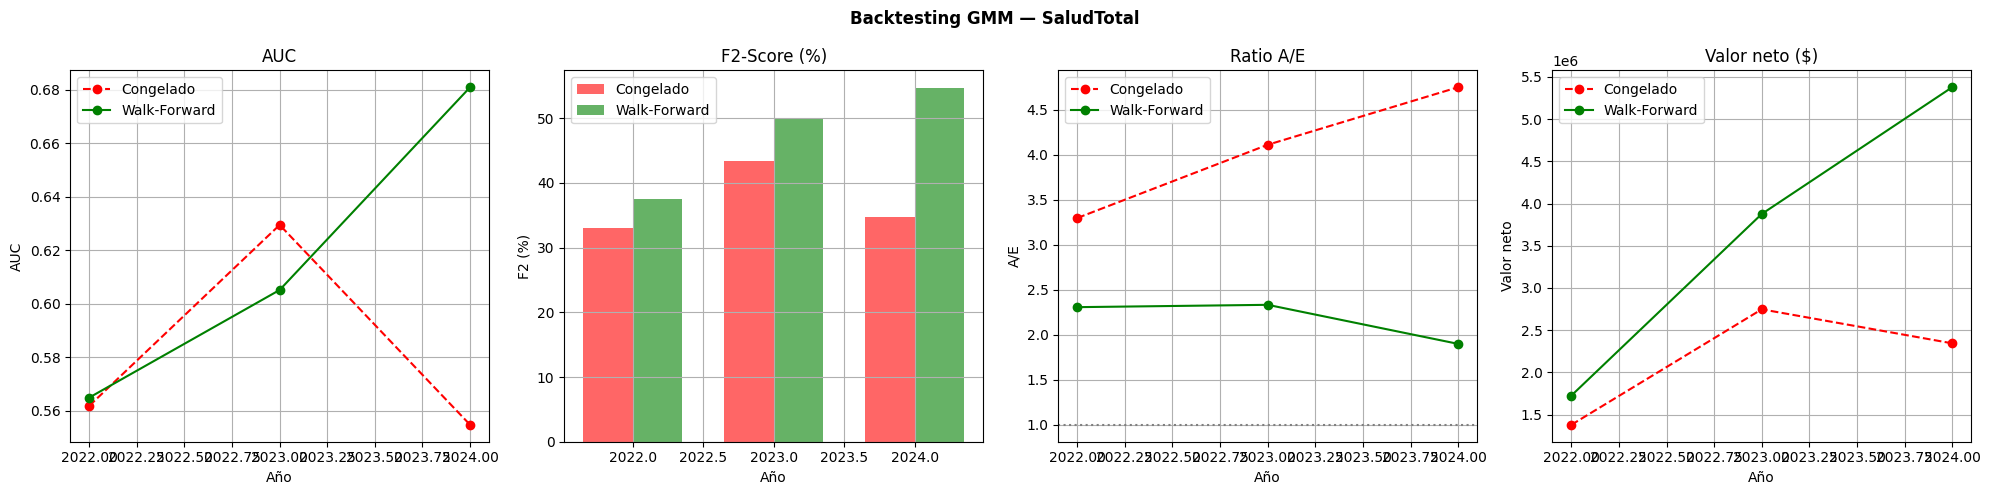

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Backtesting GMM — SaludTotal', fontweight='bold')

años_p = [r['anio'] for r in resultados_wf]

# Panel 1
ax = axes[0]
ax.plot(años_p, [r['auc_cong'] for r in resultados_wf], 'r--o', label='Congelado')
ax.plot(años_p, [r['auc_wf'] for r in resultados_wf], 'g-o', label='Walk-Forward')
ax.set_title("AUC")
ax.set_xlabel("Año")
ax.set_ylabel("AUC")
ax.legend()
ax.grid(True)

# Panel 2
ax = axes[1]
width = 0.35
ax.bar([a - width/2 for a in años_p], [r['f2_cong']*100 for r in resultados_wf],
       width, label='Congelado', color='red', alpha=0.6)
ax.bar([a + width/2 for a in años_p], [r['f2_wf']*100 for r in resultados_wf],
       width, label='Walk-Forward', color='green', alpha=0.6)
ax.set_title("F2-Score (%)")
ax.set_xlabel("Año")
ax.set_ylabel("F2 (%)")
ax.legend()
ax.grid(True)

# Panel 3
ax = axes[2]
ae_cong = [r['y_te'].sum() / r['yp_cong'].sum() for r in resultados_wf]
ae_wf   = [r['y_te'].sum() / r['yp_wf'].sum() for r in resultados_wf]
ax.plot(años_p, ae_cong, 'r--o', label='Congelado')
ax.plot(años_p, ae_wf, 'g-o', label='Walk-Forward')
ax.axhline(1.0, color='gray', linestyle=':')
ax.set_title("Ratio A/E")
ax.set_xlabel("Año")
ax.set_ylabel("A/E")
ax.legend()
ax.grid(True)

# Panel 4
ax = axes[3]
valor_cong = []
valor_wf   = []
for r in resultados_wf:
    # Valor neto con umbral por costos τ_c
    y_pred_cong = (r['yp_cong'] >= tau_c).astype(int)
    tn, fp, fn, vp = confusion_matrix(r['y_te'], y_pred_cong).ravel()
    valor_cong.append(vp * C_FN * RED_FN - (vp + fp) * C_FP)

    y_pred_wf = (r['yp_wf'] >= tau_c).astype(int)
    tn, fp, fn, vp = confusion_matrix(r['y_te'], y_pred_wf).ravel()
    valor_wf.append(vp * C_FN * RED_FN - (vp + fp) * C_FP)


ax.plot(años_p, valor_cong, 'r--o', label='Congelado')
ax.plot(años_p, valor_wf, 'g-o', label='Walk-Forward')
ax.set_title("Valor neto ($)")
ax.set_xlabel("Año")
ax.set_ylabel("Valor neto")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('ej2_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 🔧 COMPLETA: figura con 4 paneles

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Backtesting GMM — SaludTotal', fontweight='bold')

años_p = [r['anio'] for r in resultados_wf]

# Panel 1: AUC congelado (rojo punteado) vs Walk-Forward (verde)
ax = axes[0]
# --- TU CÓDIGO AQUÍ ---


# Panel 2: F2-Score de ambos modelos (barras agrupadas)
ax = axes[1]
# --- TU CÓDIGO AQUÍ ---


# Panel 3: Ratio A/E de ambos modelos
ax = axes[2]
# --- TU CÓDIGO AQUÍ ---


# Panel 4: Valor neto del backtesting por año y modelo
ax = axes[3]
# Calcula el valor neto de cada modelo y año antes de graficar
# 🔧 COMPLETA el cálculo y la gráfica
# --- TU CÓDIGO AQUÍ ---


plt.tight_layout()
plt.savefig('ej2_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 8 — Preguntas de reflexión

### 📝 Preguntas

**a)** El modelo congelado tiene A/E alejado de 1.0 en 2024. ¿Está sobreestimando o
subestimando? ¿Cuál es el impacto para el área de Gestión de Salud si el A/E > 1.1?
¿Y si el A/E < 0.9?

> Como el A/E = Reales / Esperados, un valor > 1.0 significa que hubo más casos reales que los esperados.
En este caso, el modelo subestima: predice muy pocos siniestros altos frente a los que realmente ocurren.
A/E > 1.1 = subestimación peligrosa → se pierden pacientes críticos sin alerta.
A/E < 0.9 = sobreestimación costosa → se malgastan recursos en pacientes de bajo riesgo.

---

**b)** Con τ = 0.50 casi no se detecta ningún caso de alto costo. ¿Por qué?
Relaciona tu respuesta con la prevalencia del problema (9–15%) y con el hecho de
que el modelo produce probabilidades continuas.

> Todas las τ <= 0.5 generan más VP y detectan la prevalencia real de siniestros de más alto costo. 

---

**c)** El F2-Score penaliza más los FN que los FP. ¿En qué situación de negocio
sería correcto usar F1-Score en lugar de F2-Score? ¿Existe ese escenario en seguros?

> El F1-Score sería adecuado cuando los FP y FN tienen una importancia similar para el negocio, es decir, cuando no se quiere priorizar especialmente la detección de todos los casos positivos.
Un ejemplo de escenario en seguros sería el siguiente: si tanto generar una alerta innecesaria como no detectar un caso de riesgo tienen costos o consecuencias similares, sería razonable usar F1-Score. Sin embargo, en este ejercicio de GMM se utiliza F2-Score porque un falso negativo —no detectar un siniestro de alto costo— tiene mayor impacto, por lo que es más importante reducirlos.

---

**d) BONUS — Ventana óptima de re-entrenamiento para 2024:**
Compara: train largo (2018–2023) vs reciente (2021–2023) vs solo último año (2023).
¿Cuál da el AUC más alto? ¿Y el mayor F2-Score? ¿Son siempre la misma estrategia?

```python
# 🔧 BONUS
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24  = df.loc[mask_test_24, 'siniestro_alto'].values

for nombre, anios_tr in [
    ("Largo (2018-2023)",    list(range(2018,2024))),
    ("Reciente (2021-2023)", [2021,2022,2023]),
    ("Solo 2023",            [2023]),
]:
    # --- TU CÓDIGO AQUÍ ---
    pass
```

In [13]:
# 🔧 BONUS
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24  = df.loc[mask_test_24, 'siniestro_alto'].values

for nombre, anios_tr in [
    ("Largo (2018-2023)",    list(range(2018,2024))),
    ("Reciente (2021-2023)", [2021,2022,2023]),
    ("Solo 2023",            [2023]),
]:
    
    mask_train = df['anio'].isin(anios_tr)
    X_tr = df.loc[mask_train, FEATURES].values
    y_tr = df.loc[mask_train, 'siniestro_alto'].values

    pipe_bonus = Pipeline([
        ('sc', StandardScaler()),
        ('m', GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                         learning_rate=0.08, random_state=2024))
    ])
    pipe_bonus.fit(X_tr, y_tr)
    yp_bonus = pipe_bonus.predict_proba(X_te24)[:,1]

    auc_bonus = roc_auc_score(y_te24, yp_bonus)
    f2_bonus  = fbeta_score(y_te24, (yp_bonus>=tau_c).astype(int),
                            beta=2, zero_division=0)

    print(f"{nombre:20}  AUC={auc_bonus:.4f}  F2={f2_bonus*100:.1f}%")

Largo (2018-2023)     AUC=0.6810  F2=54.7%
Reciente (2021-2023)  AUC=0.6952  F2=54.8%
Solo 2023             AUC=0.6863  F2=55.6%
